In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [17]:
# Load data hasil K-Means
df = pd.read_excel("data/data_hasil_kmeans.xlsx")

In [18]:
# Fitur prediktor
X = df[
    [
        'Besar Pinjaman',
        'Sisa Pinjaman',
        'Angsuran Pokok',
        'Tenor',
        'Tunggakan Maksimum'
    ]
]


In [19]:
# Pseudo-label hasil K-Means
y = df['Risiko']

In [20]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# Model Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [22]:
# Training
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [23]:
# Prediksi
y_pred = rf.predict(X_test)

In [24]:
# Evaluasi
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9894736842105263

Classification Report
              precision    recall  f1-score   support

      Rendah       0.99      1.00      0.99        80
      Sedang       1.00      0.80      0.89         5
      Tinggi       1.00      1.00      1.00        10

    accuracy                           0.99        95
   macro avg       1.00      0.93      0.96        95
weighted avg       0.99      0.99      0.99        95


Confusion Matrix
[[80  0  0]
 [ 1  4  0]
 [ 0  0 10]]


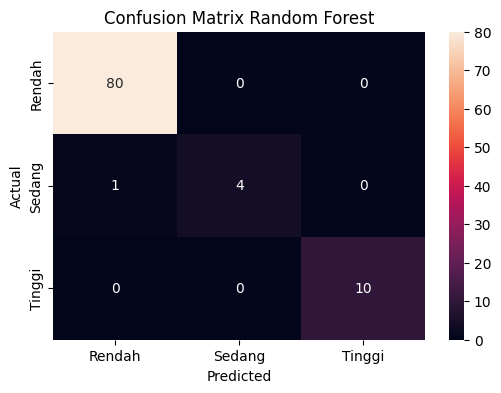

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Rendah','Sedang','Tinggi'],
    yticklabels=['Rendah','Sedang','Tinggi']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Random Forest")
plt.show()

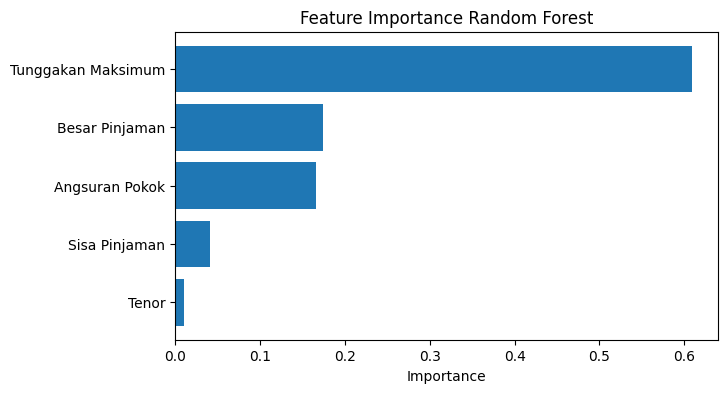

In [26]:
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(7,4))
plt.barh(importance['Fitur'], importance['Importance'])
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.show()

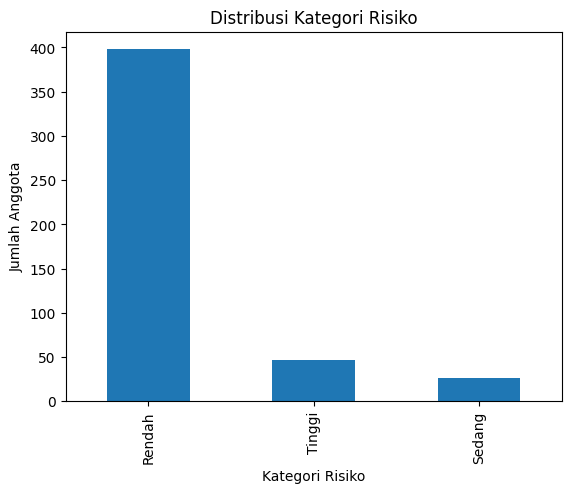

In [27]:
df['Risiko'].value_counts().plot(kind='bar')

plt.title("Distribusi Kategori Risiko")
plt.xlabel("Kategori Risiko")
plt.ylabel("Jumlah Anggota")
plt.show()

In [28]:
import os
import joblib

os.makedirs('model', exist_ok=True)

joblib.dump(rf, 'model/random_forest_model.pkl')

print("Model Hybrid RF berhasil disimpan!")

Model Hybrid RF berhasil disimpan!
